In [5]:
import pandas as pd
import re

# Load your results file
df = pd.read_csv('results\parse_tree_distances.csv')

# Function to extract language code from 'augment_xx_xx'
def extract_lang(col):
    match = re.match(r'augment_([a-z]{2})_', col)
    return match.group(1) if match else col

# Build the rename dictionary for relevant columns
rename_dict = {col: extract_lang(col) for col in df.columns if col.startswith('augment_')}
df.rename(columns=rename_dict, inplace=True)

# Save the cleaned file
df.to_csv('results\parse_tree_distances_langcode.csv', index=False)


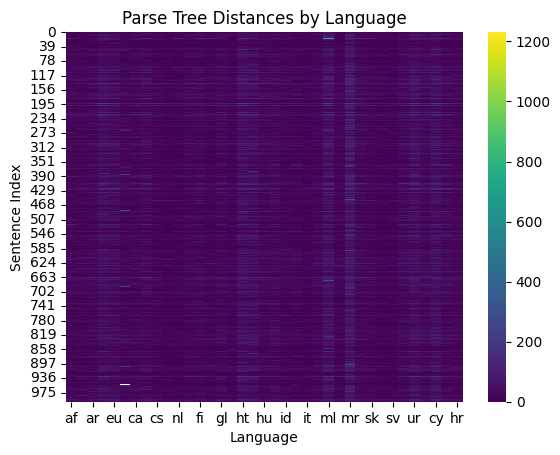

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_csv('results\parse_tree_distances_langcode.csv')

# Optionally, drop non-language columns like 'row' or 'text'
lang_cols = [col for col in df.columns if col not in ['row', 'text']]
sns.heatmap(df[lang_cols], cmap='viridis')
plt.title('Parse Tree Distances by Language')
plt.xlabel('Language')
plt.ylabel('Sentence Index')
plt.show()


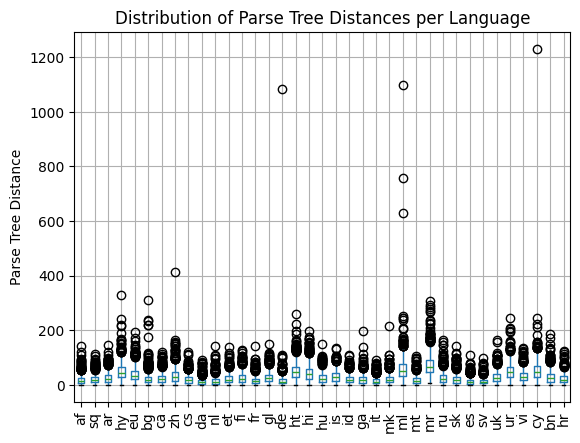

In [10]:
import matplotlib.pyplot as plt

df[lang_cols].boxplot(rot=90)
plt.title('Distribution of Parse Tree Distances per Language')
plt.ylabel('Parse Tree Distance')
plt.show()


In [ ]:
print(df[lang_cols].describe().T[['mean', 'std', 'min', 'max']])

         mean        std  min     max
af  18.350000  16.306238  0.0   141.0
sq  20.031000  15.543411  0.0   114.0
ar  25.227000  19.026336  0.0   147.0
hy  49.036036  31.822477  0.0   328.0
eu  38.872000  26.546682  0.0   193.0
bg  23.477477  24.201626  0.0   310.0
ca  24.129000  18.477331  0.0   121.0
zh  34.495000  28.216310  0.0   415.0
cs  19.573000  15.994515  0.0   121.0
da  12.452000  12.131648  0.0    91.0
nl  14.087000  14.454631  0.0   141.0
et  23.078000  17.264472  0.0   137.0
fi  25.534000  19.525627  0.0   128.0
fr  16.307000  14.901571  0.0   142.0
gl  27.975000  19.710273  0.0   149.0
de  17.221000  36.791164  0.0  1083.0
ht  51.572000  30.918389  0.0   260.0
hi  43.072000  29.333927  0.0   196.0
hu  24.709710  18.644061  0.0   151.0
is  30.721000  20.844271  0.0   134.0
id  20.955000  15.602577  0.0   110.0
ga  19.655000  17.665901  0.0   196.0
it  14.444000  13.121320  0.0    92.0
mk  22.140000  17.326240  0.0   214.0
ml  58.614000  56.153898  0.0  1099.0
mt  17.17500

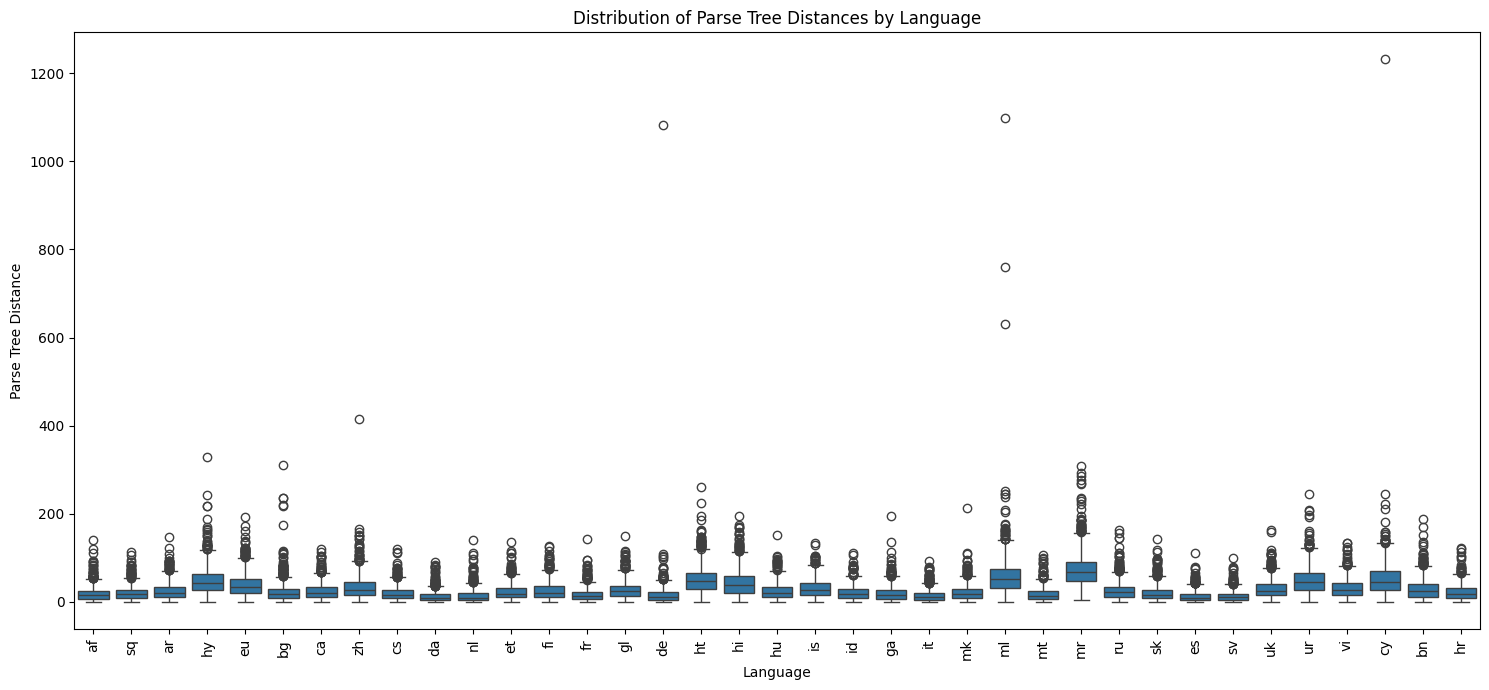

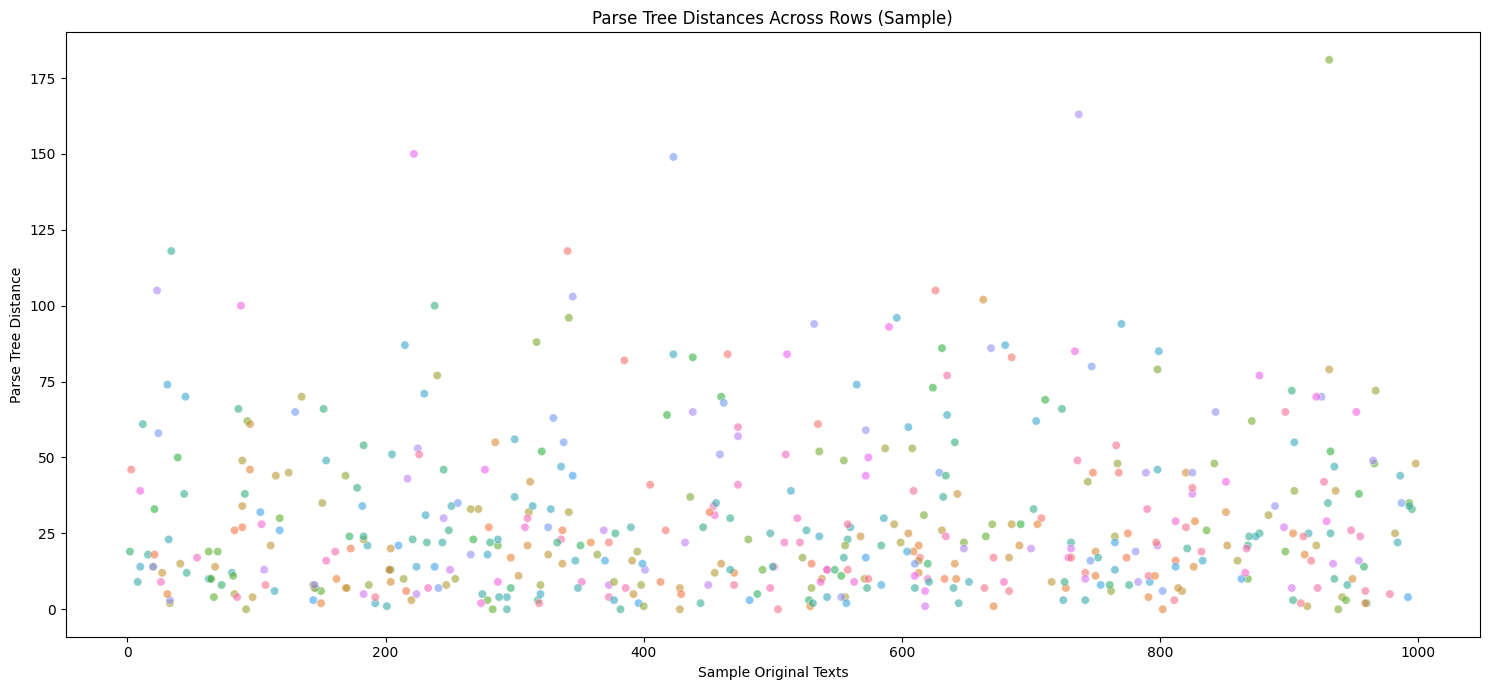

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the results
results_df = pd.read_csv('results\parse_tree_distances_langcode.csv')

# Select parse tree distance columns
lang_cols = [col for col in df.columns if col not in ['row', 'text']]

# Melt to long format for plotting
melted_df = results_df.melt(
    id_vars=['row', 'text'],
    value_vars=lang_cols,
    var_name='language',
    value_name='parse_tree_distance'
)
#melted_df['language'] = melted_df['language'].str.replace('_parse_tree_distance', '')
melted_df = melted_df.dropna(subset=['parse_tree_distance'])

# Boxplot
plt.figure(figsize=(15, 7))
sns.boxplot(data=melted_df, x='language', y='parse_tree_distance')
plt.xticks(rotation=90)
plt.title('Distribution of Parse Tree Distances by Language')
plt.ylabel('Parse Tree Distance')
plt.xlabel('Language')
plt.tight_layout()
plt.show()

# Scatter plot (sample up to 500 points for clarity)
plt.figure(figsize=(15, 7))
sns.scatterplot(
    data=melted_df.sample(min(500, len(melted_df))),
    x='row', y='parse_tree_distance', hue='language', legend=None, alpha=0.6
)
plt.title('Parse Tree Distances Across Rows (Sample)')
plt.ylabel('Parse Tree Distance')
plt.xlabel('Sample Original Texts')
plt.tight_layout()
plt.show()


In [11]:
import nltk
from nltk.tree import Tree
import benepar
from zss import simple_distance, Node

# Load the benepar parser
parser = benepar.Parser("benepar_en3")

def sentence_to_tree(sentence):
    """Parse a sentence into an NLTK Tree using benepar."""
    sent = nltk.word_tokenize(sentence)
    tree = parser.parse(sent)
    return tree

def nltk_tree_to_zss(tree):
    """Convert NLTK Tree to zss.Node for tree edit distance computation."""
    node = Node(str(tree.label()))
    for child in tree:
        if isinstance(child, Tree):
            node.addkid(nltk_tree_to_zss(child))
        else:
            # For leaves, add as a child node
            node.addkid(Node(str(child)))
    return node

def compute_tree_edit_distance(tree1, tree2):
    """Compute tree edit distance between two NLTK Trees."""
    node1 = nltk_tree_to_zss(tree1)
    node2 = nltk_tree_to_zss(tree2)
    return simple_distance(node1, node2)

def draw_tree(tree, title="Parse Tree"):
    """Draw the NLTK parse tree."""
    print(title)
    tree.pretty_print()

def process_sentence_pairs(pairs):
    """
    pairs: list of (original, back_translated) tuples
    """
    results = []
    for idx, (orig, aug) in enumerate(pairs):
        print(f"\nPair {idx+1}:")
        print("Original:      ", orig)
        print("Back-translated:", aug)
        try:
            tree_orig = sentence_to_tree(orig)
            tree_aug = sentence_to_tree(aug)
            dist = compute_tree_edit_distance(tree_orig, tree_aug)
            print("Tree Edit Distance:", dist)
            print("Original Parse Tree:")
            draw_tree(tree_orig)
            print("Back-Translated Parse Tree:")
            draw_tree(tree_aug)
            results.append({'pair': (orig, aug), 'distance': dist})
        except Exception as e:
            print("Error parsing or computing distance:", e)
            results.append({'pair': (orig, aug), 'distance': None})
    return results

# Example input
sentence_pairs = [
    ("A family member or a support person may stay with a patient during recovery.", "A family member or any support person may be with the patient while recovering."), # কোনও পরিবারের সদস্য বা কোনও সমর্থন ব্যক্তি পুনরুদ্ধারের সময় রোগীর সাথে থাকতে পারেন।, A family member or any support person may be with the patient while recovering.
    # Add more pairs as needed
]

# Run the process
results = process_sentence_pairs(sentence_pairs)


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
You're using a T5TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Pair 1:
Original:       A family member or a support person may stay with a patient during recovery.
Back-translated: A family member or any support person may be with the patient while recovering.


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
c:\Program Files\Python310\lib\site-packages\torch\distributions\distribution.py:56: UserWarning: <class 'torch_struct.distributions.TreeCRF'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


Tree Edit Distance: 9.0
Original Parse Tree:
Parse Tree
                                         TOP                                                  
                                          |                                                    
                                          S                                                   
                    ______________________|_________________________________________________   
                   |                          VP                                            | 
                   |                       ___|_________                                    |  
                   |                      |             VP                                  | 
                   |                      |    _________|______________________             |  
                   NP                     |   |         PP                     PP           | 
       ____________|_________             |   |     ____|___              _____|_____